In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys

PDM_DIR = os.environ.get('PDM_DIR', '../../../PDM')
sys.path.append(f'{PDM_DIR}/src')

import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../..')
import matplotlib.pyplot as plt

from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import (
    load_mem_results_scores_grid,
    load_long_inference_state_norm_grid,
    load_long_inference_state_norm_by_layer_grid,
)
from attn_bench.plotting.heatmap import plot_models_heatmap_panel
from attn_bench.plotting.utils import SEQ_LEN
from attn_bench.plotting.gdn_state import plot_state_norm_panel, plot_state_norm_by_layer

# GDN variants: state reset boundary

The state matrix can be reset at the document boundary (xdoc masking) or at the sequence boundary (xseq masking). The latter can also happen with some probability. We're comparing the following models:
- **gdn** (reset at both boundaries)
- **gdn-xdl** (leaking at xdoc boundary, reset at xseq boundary)
- **gdn-xdl-xsl-0.5** (leaking at xdoc boundary, leaking at xseq boundary with 50% probability)
- **gdn-xdl-xsl** (leaking at xdoc boundary, leaking at xseq boundary)

## Load memorization results

In [3]:
MEM_MODELS = ['gdn', 'gdn-xdl', 'gdn-xdl-xsl-0.5', 'gdn-xdl-xsl']

OFFSETS = [0, 1, 5, 12, 25, 50, 100, 500, 1000]
PREFIXES = [50, 100, 250, 500, 750, 1000, 2000, 3000]
SUFFIXES = [50, 500]

results_grid = load_mem_results_scores_grid(
    OFFSETS, PREFIXES, SUFFIXES, models=MEM_MODELS, results_base=model_registry.MEM_RESULTS_DIR
)

## Rouge-L
### Offsets

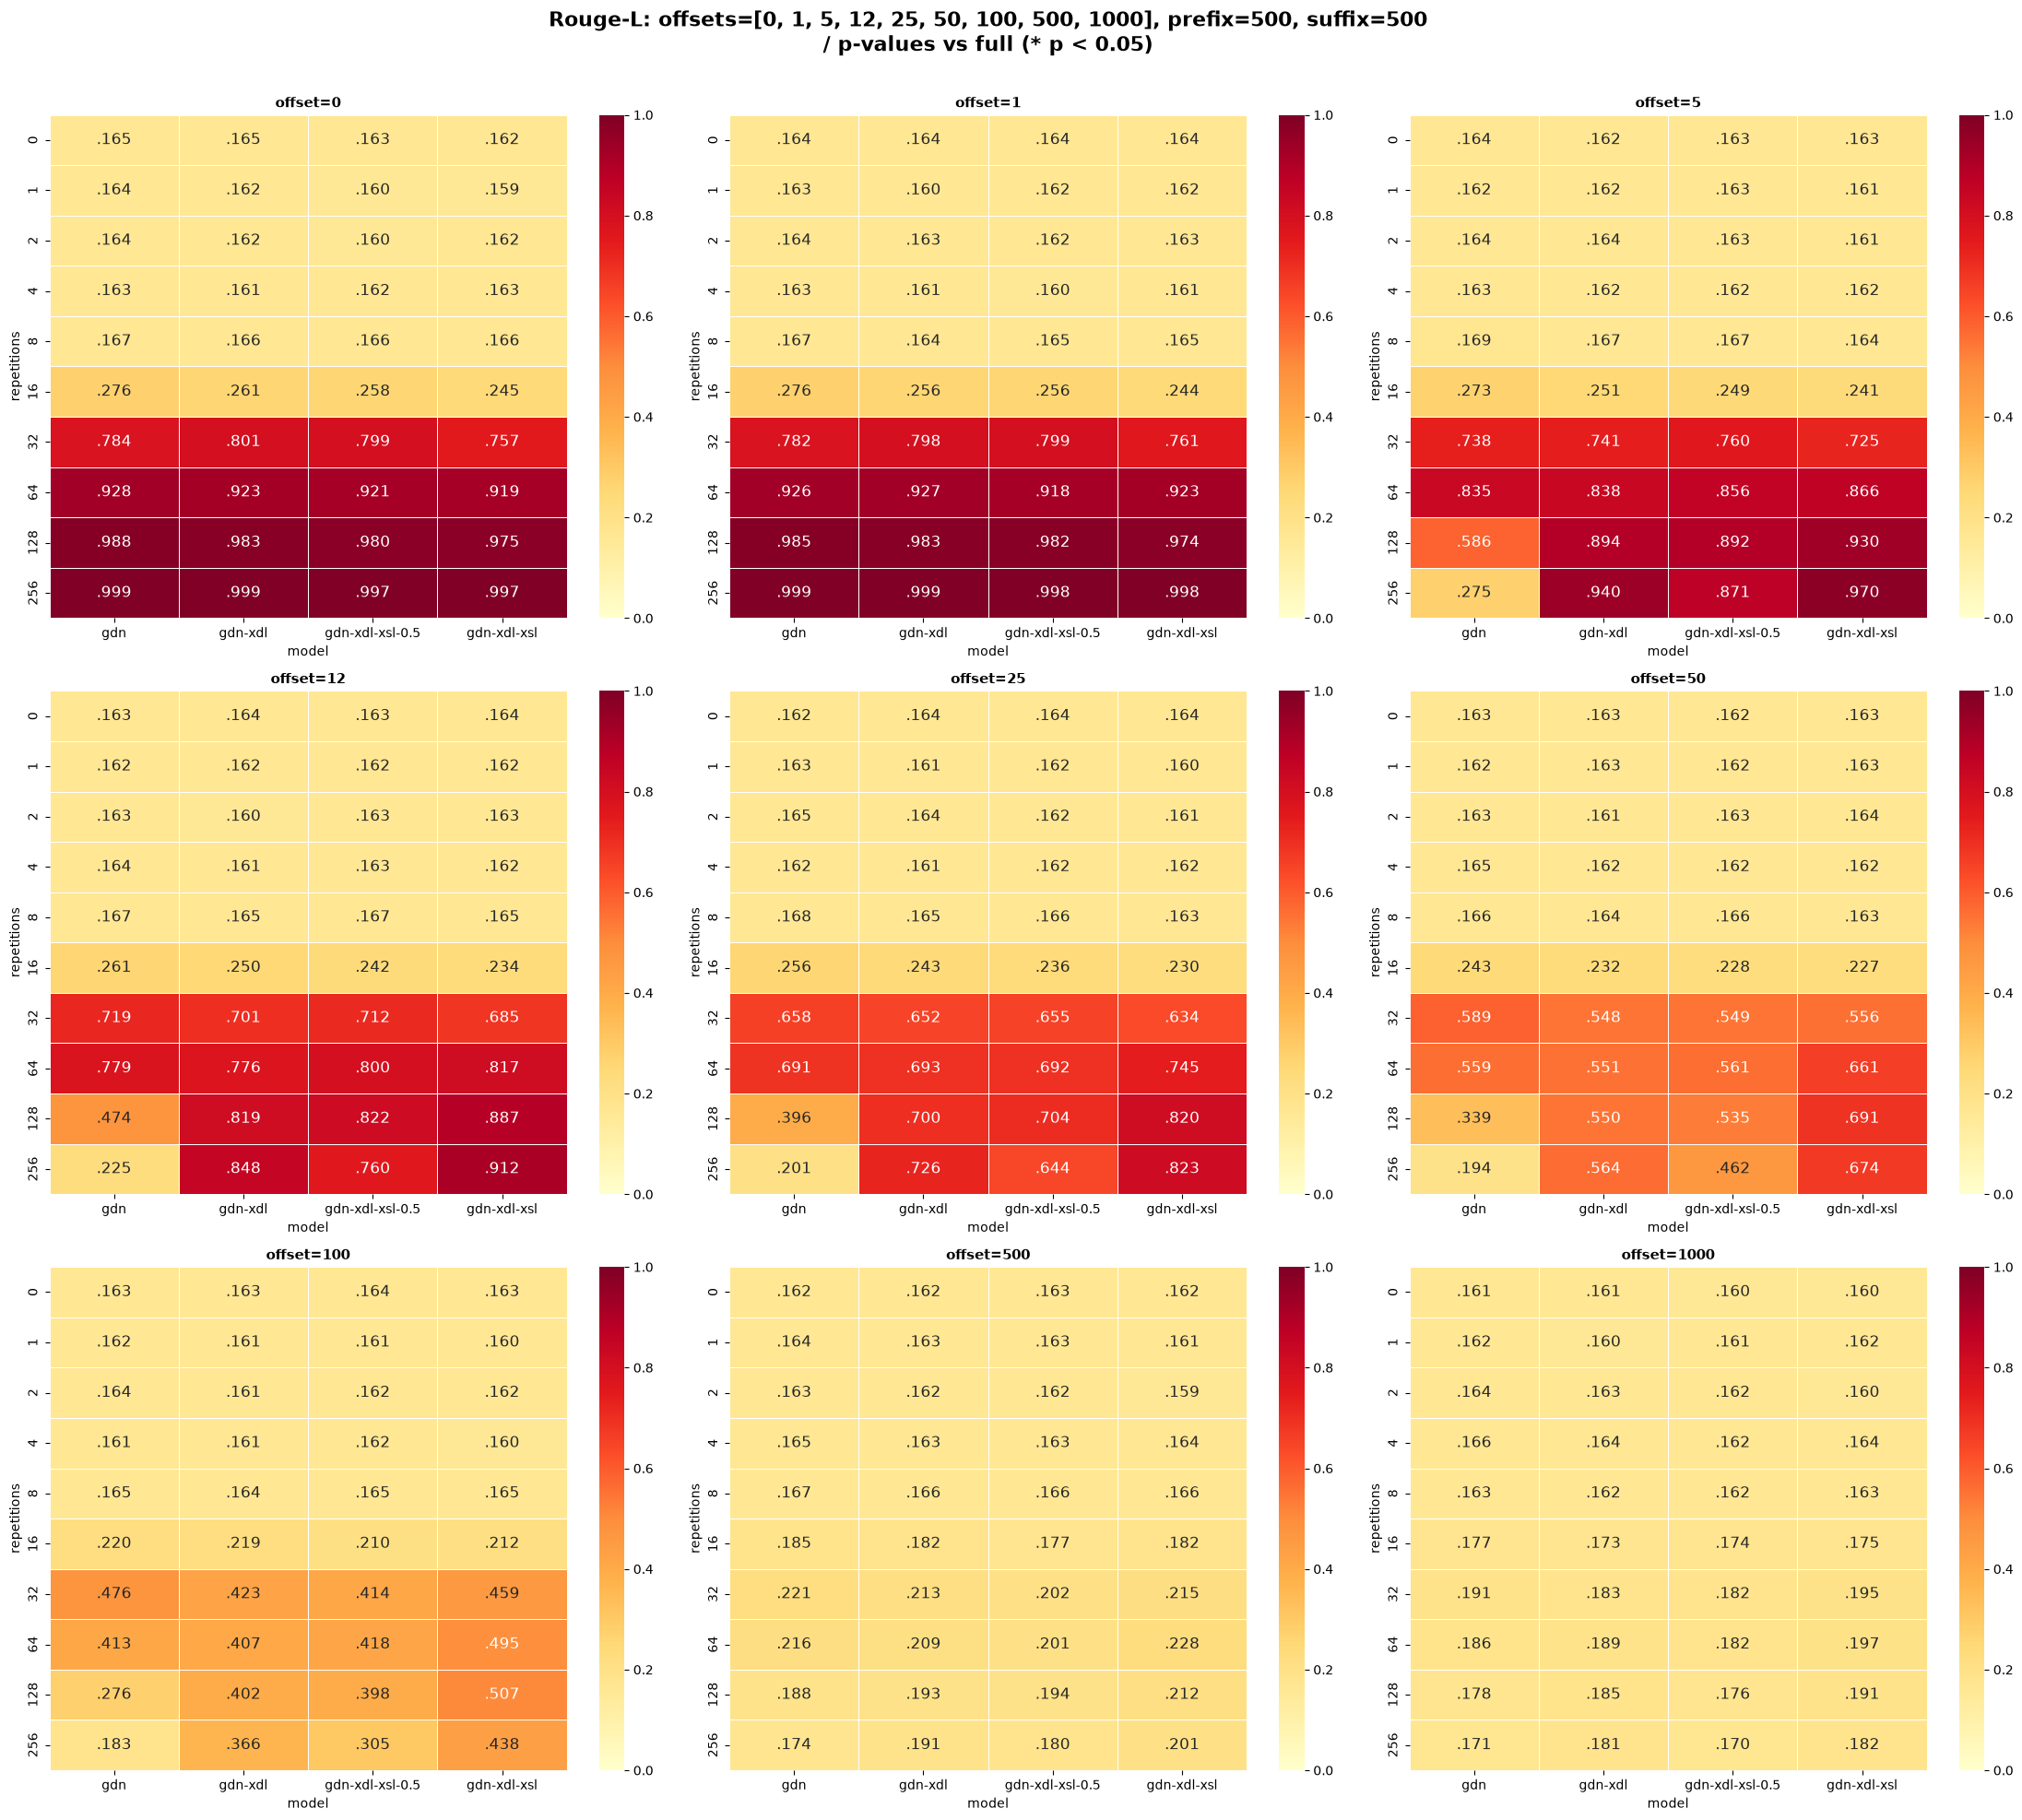

In [4]:
plot_models_heatmap_panel(
    results_grid, 'Rouge-L', models=MEM_MODELS, panels='offset', values=OFFSETS, fixed_prefix=500, fixed_suffix=500, ncols=3
)

### Prefixes

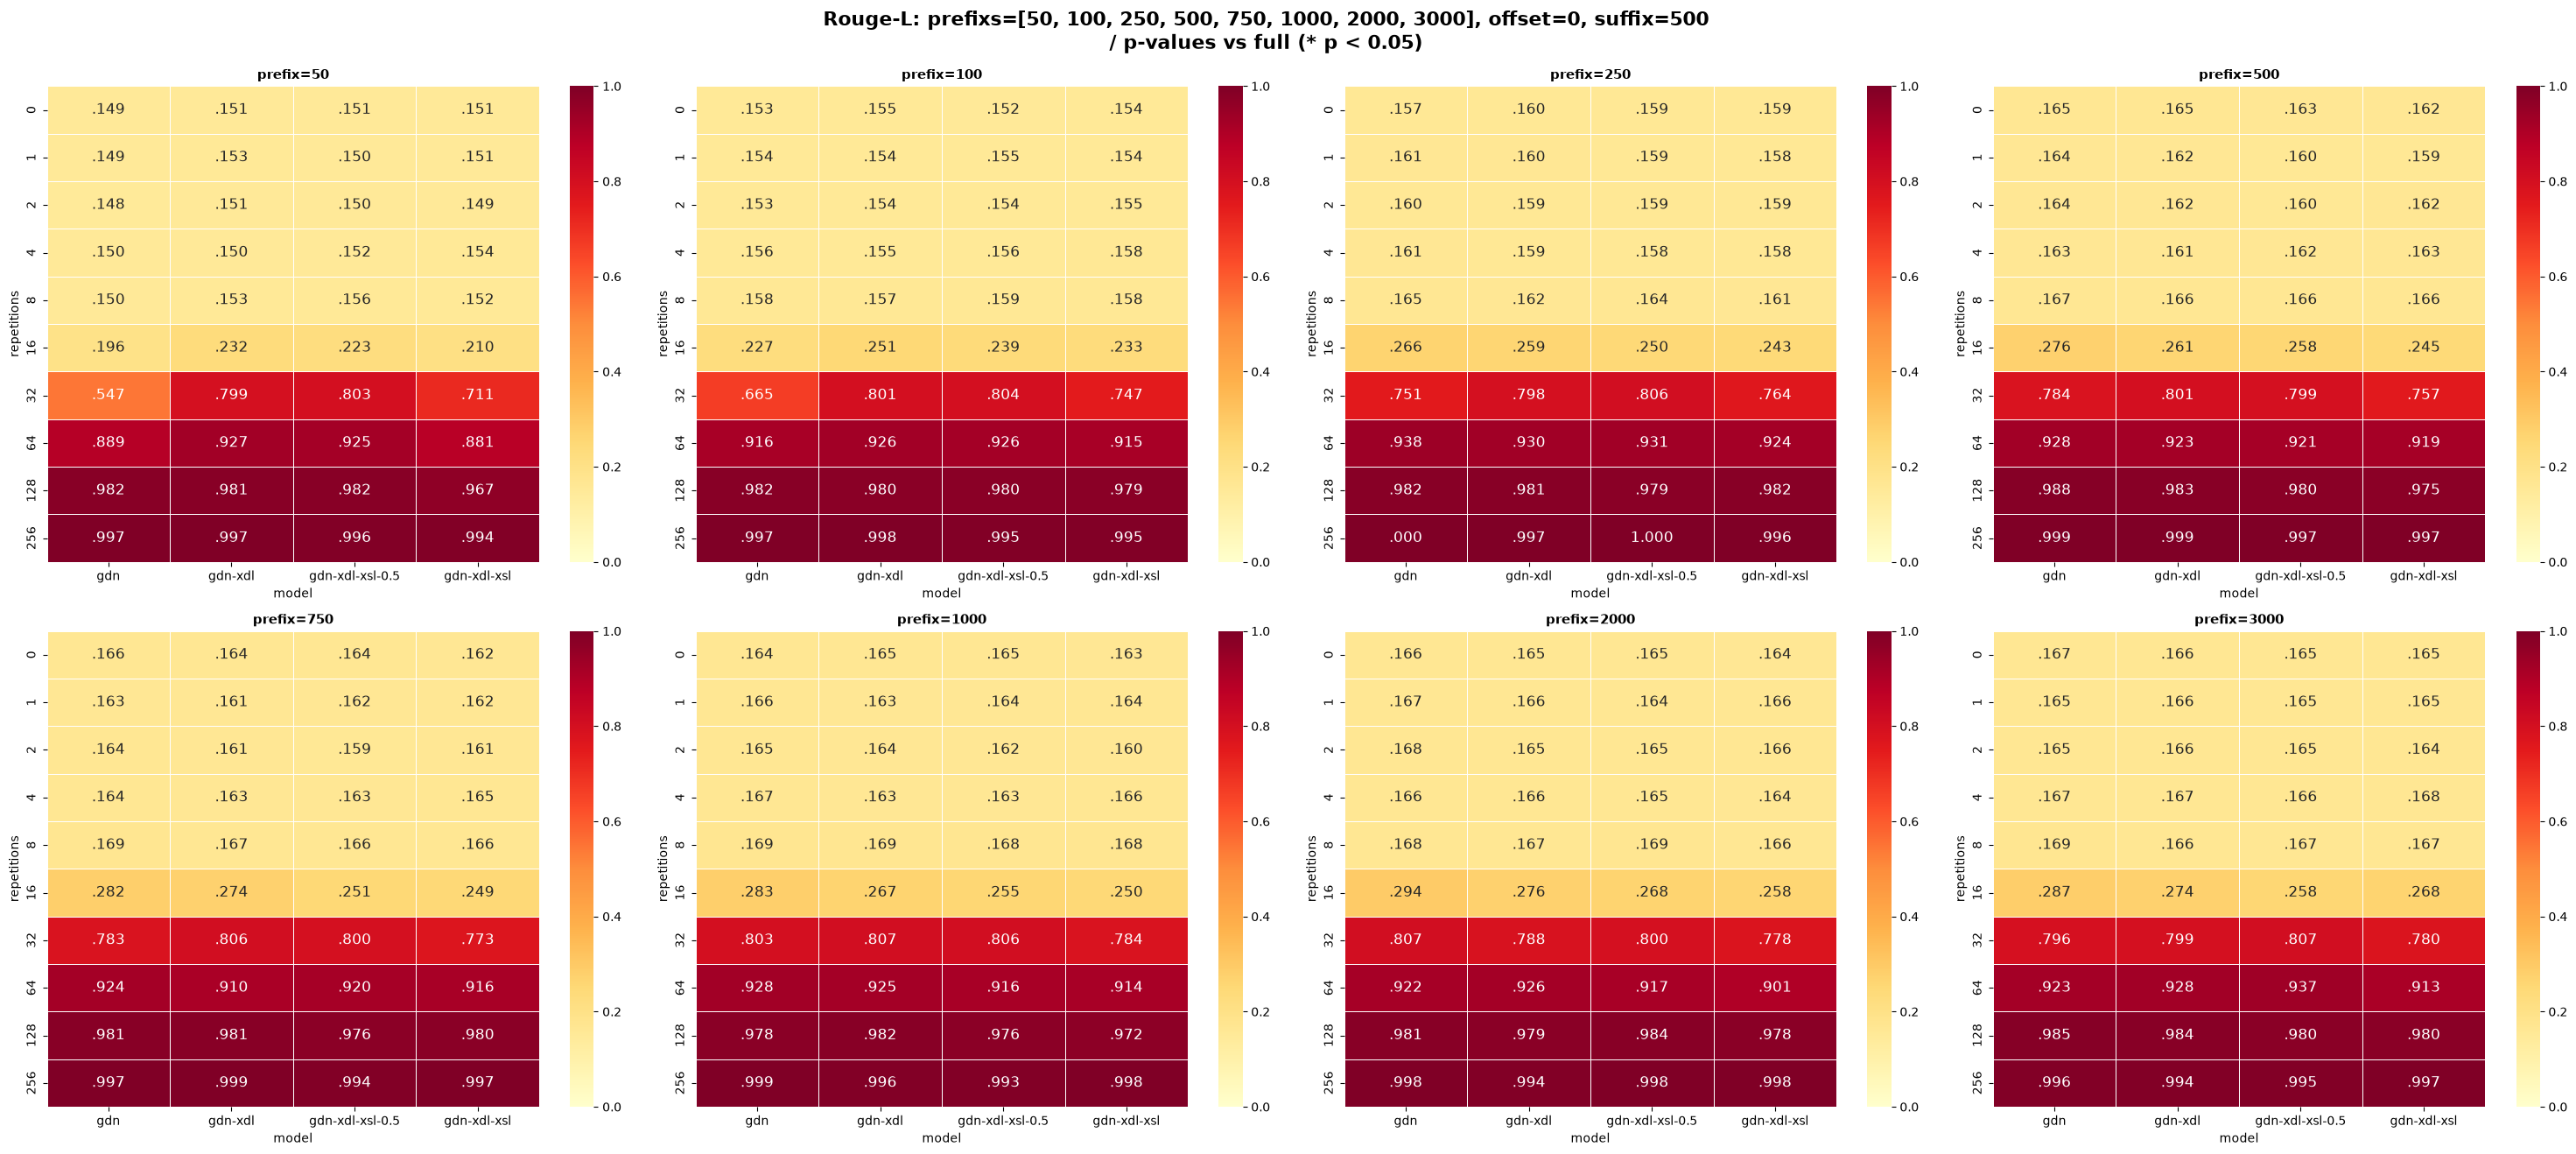

In [5]:
plot_models_heatmap_panel(results_grid, 'Rouge-L', models=MEM_MODELS,
                          panels='prefix', values=PREFIXES, fixed_offset=0, fixed_suffix=500, ncols=4)

## State norms

### Along the sequence

One cell per repetition bucket: GDN state norm (Frobenius, averaged over layers/heads) vs
token position. Dotted line at 8192 = training length; past it, the model is running on
lengths it never trained on.

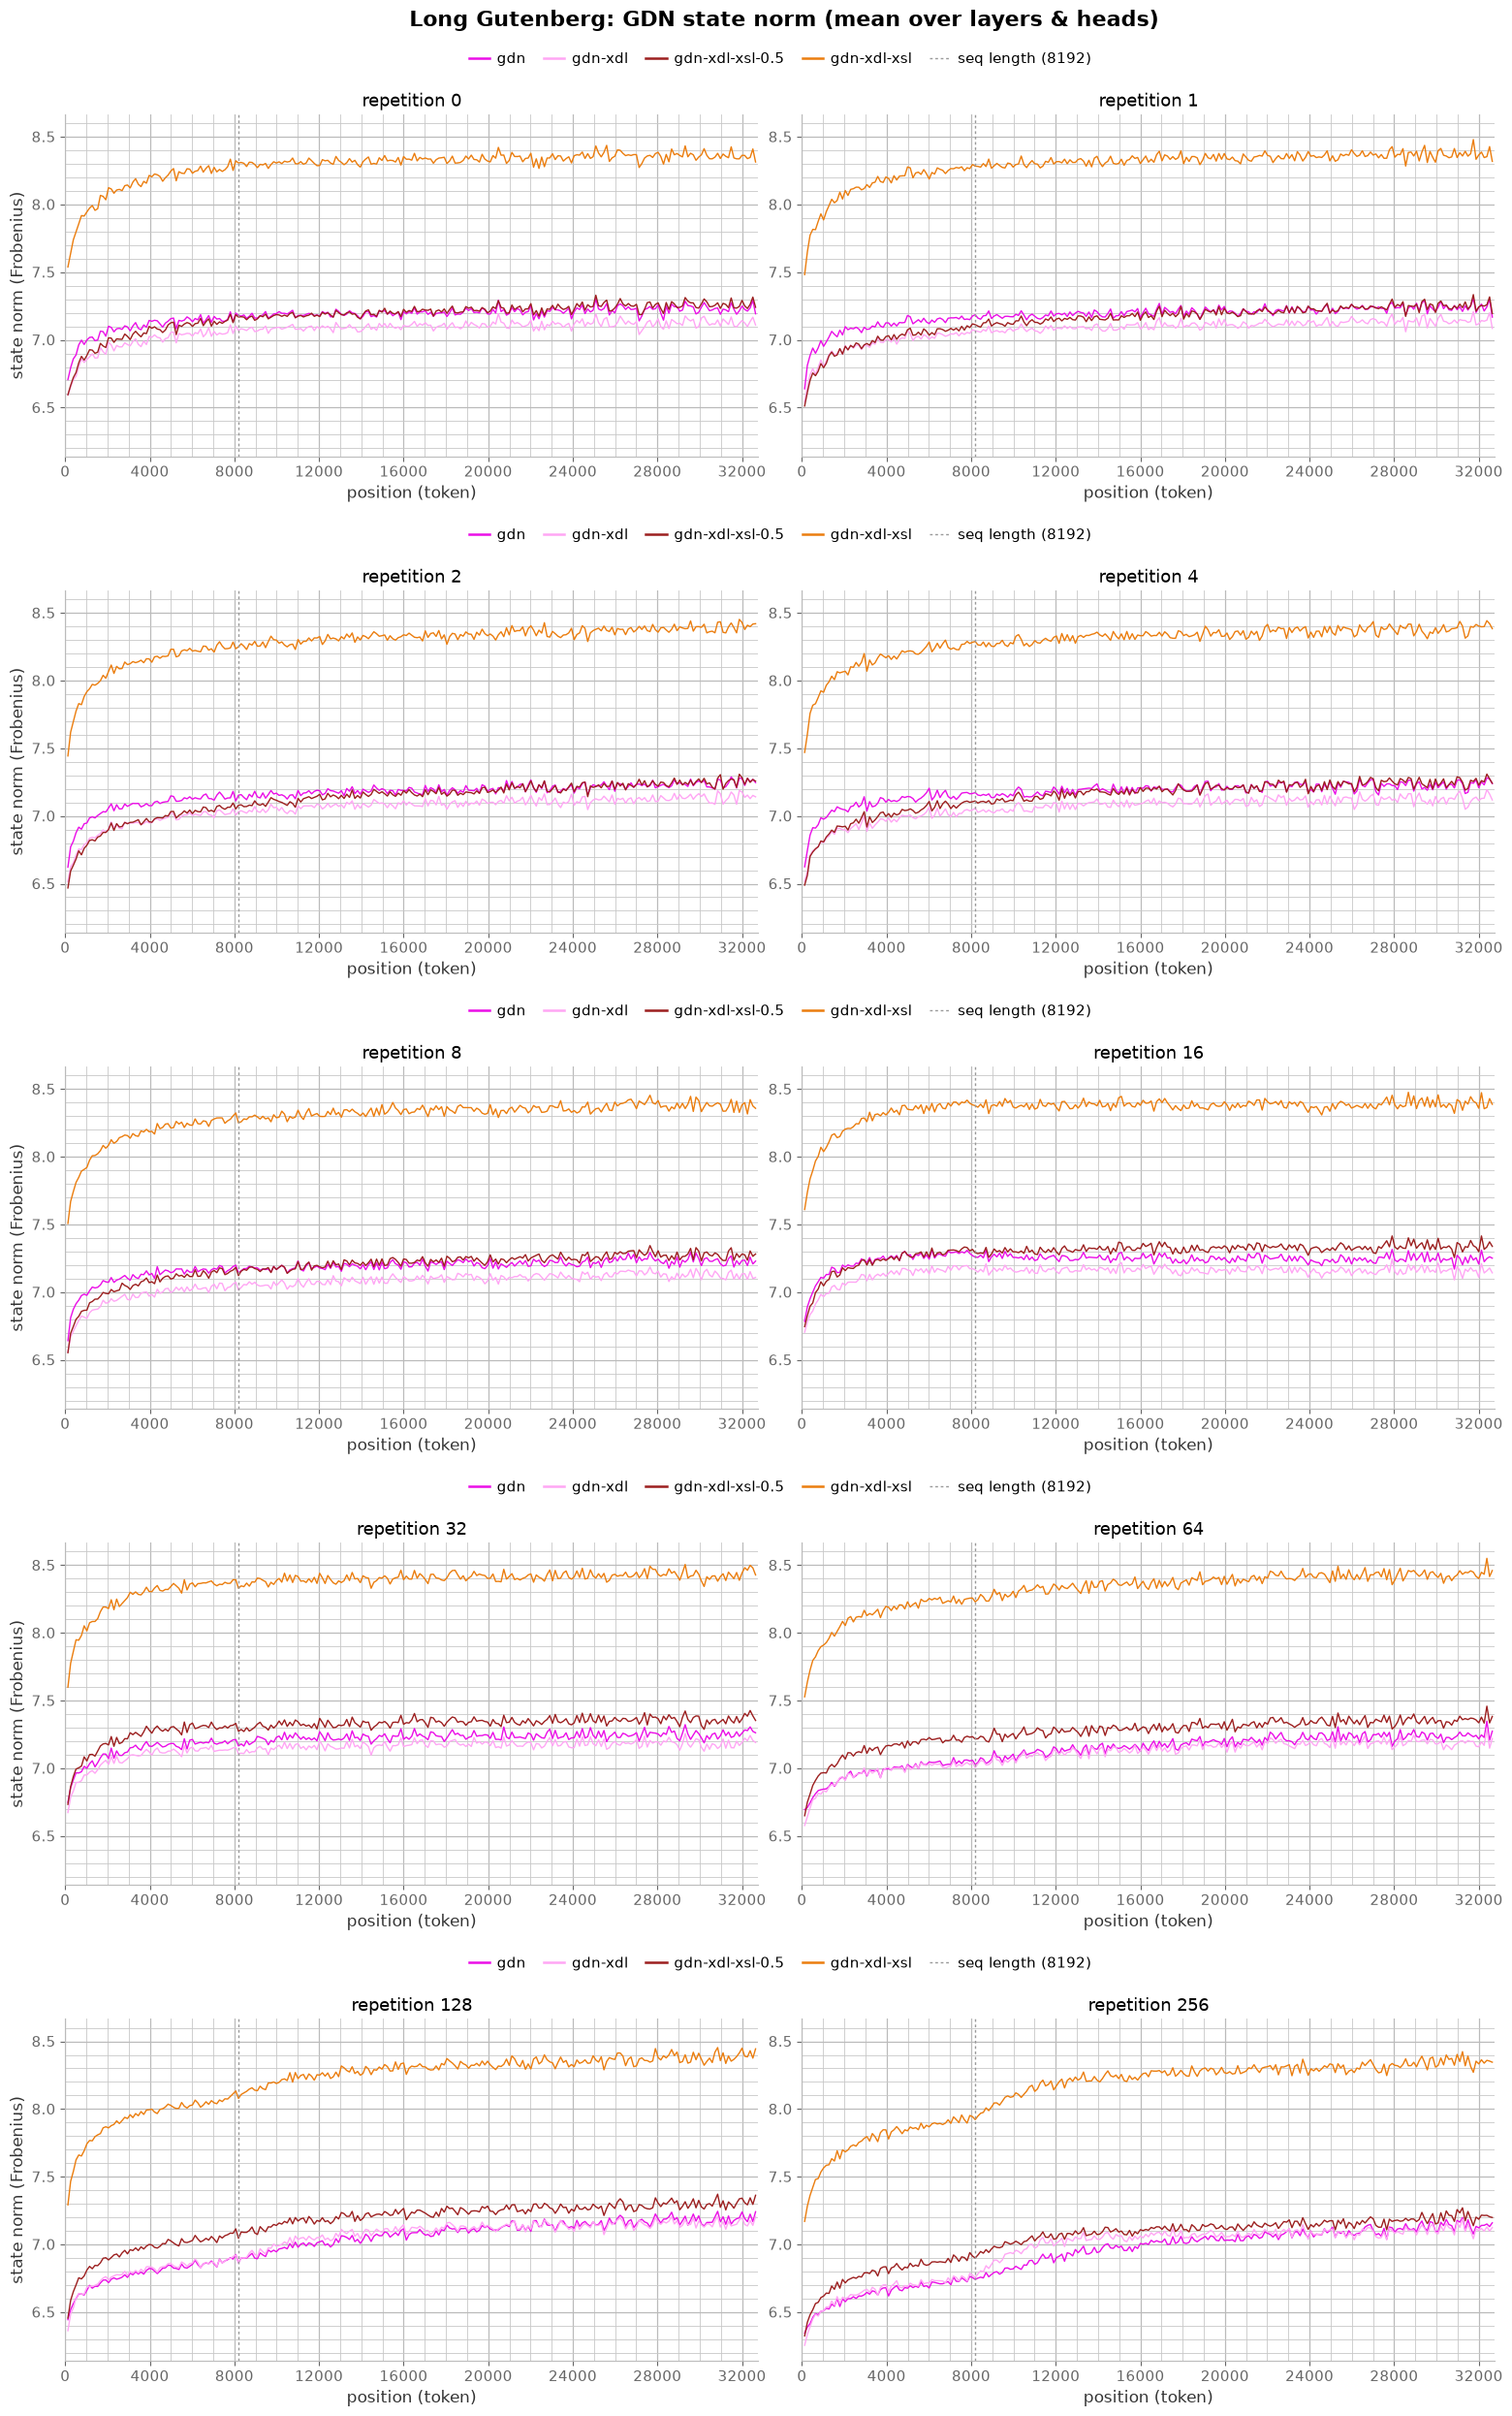

In [6]:
REPS = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]

# The norms are already averaged over many samples, so no smoothing is needed.
state_by_label = load_long_inference_state_norm_grid(REPS, models=MEM_MODELS)
fig = plot_state_norm_panel(state_by_label, ncols=2, smooth_window=0, xmax=4 * SEQ_LEN,
                            show_std=False, sharey=True,
                            suptitle='Long Gutenberg: GDN state norm (mean over layers & heads)',
                            colors=model_registry.MODEL_COLORS)
plt.show()

### By layer

Per-layer breakdown of the overview above, for one repetition (`REP`): 16 head-averaged
layer lines per model, dark (layer 1) to bright (layer 16).

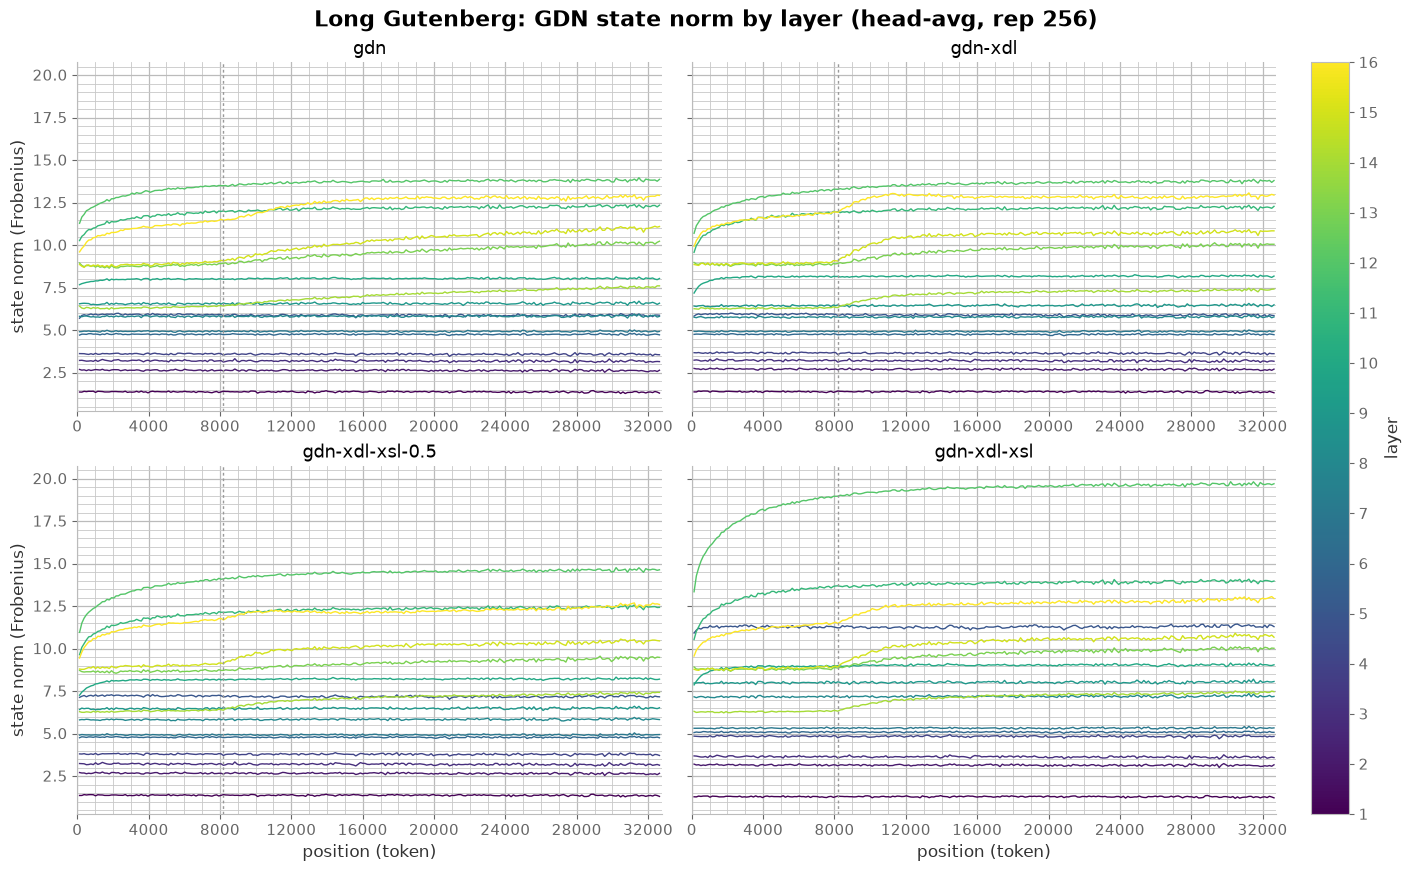

In [7]:
# REP picks the bucket; re-run with a different value to compare.
# Reuses state_by_label's models (the four GDN variants) from the cell above.
REP = 256
state_by_layer = load_long_inference_state_norm_by_layer_grid(REP, models=MEM_MODELS)
fig = plot_state_norm_by_layer(state_by_layer, xmax=4 * SEQ_LEN,
                               suptitle=f'Long Gutenberg: GDN state norm by layer (head-avg, rep {REP})')
plt.show()